# Evaluating logistic regression

CSI4106 Introduction to Artificial Intelligence

Marcel Turcotte (School of Electrical Engineering and Computer Science,
University of Ottawa)  
2026-09-19

This notebook retains the logistic-regression implementation from
Lecture 6 so that it can run independently. The main focus is model
evaluation: classification reports, confusion matrices, ROC curves, AUC,
and the effect of changing the classification threshold.

# Logistic regression implementation

The class adds the intercept internally and follows the same
binary-cross-entropy and batch-gradient-descent equations used in
Lecture 6.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml, load_breast_cancer, make_blobs
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class LogisticRegression:

    """
    Binary logistic regression trained with batch gradient descent.

    Parameters
    ----------
    learning_rate : float, default=0.1
        Step size for gradient descent.
    max_iter : int, default=1000
        Number of gradient descent iterations.
    Notes
    -----
    - This implementation expects binary labels {0, 1}.
    - The intercept (bias) term is added internally during `fit`.
    - For simplicity, there is no regularization and no early stopping.
    """

    def __init__(self, learning_rate: float = 0.1, max_iter: int = 1000):
        if learning_rate <= 0:
            raise ValueError("learning_rate must be positive.")
        if max_iter <= 0:
            raise ValueError("max_iter must be positive.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter

        # Attributes set after fitting
        self._theta = None             # shape: (n_features + 1,) including intercept
        self._loss_history = None      # list of floats
        self._n_features = None        # number of features seen in X during fit (without intercept)
        self._fitted = False

    # ---------- Public API ----------

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """
        Fit the model parameters using gradient descent.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Feature matrix (NO intercept column; it will be added internally).
        y : array-like, shape (n_samples,)
            Binary target labels in {0, 1}.

        Returns
        -------
        self : LogisticRegression
        """
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must contain the same number of examples.")
        self._check_binary_labels(y)

        m, n = X.shape
        self._n_features = n

        # Add intercept column of ones
        Xb = self._add_intercept(X)

        # Zero initialization is sufficient because the objective is convex.
        self._theta = np.zeros(n + 1, dtype=float)

        self._loss_history = []

        # Gradient descent
        for _ in range(self.max_iter):
            z = Xb @ self._theta
            h = self._sigmoid(z)                       # predicted probabilities
            grad = (Xb.T @ (h - y)) / m                # gradient of binary cross-entropy
            self._theta -= self.learning_rate * grad   # update
            updated_h = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(self._bce_loss(updated_h, y))

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Return predicted probabilities for the positive class.

        Raises
        ------
        RuntimeError : if called before fit
        ValueError : if X has a different number of features than seen in fit
        """
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)

        Xb = self._add_intercept(X)
        return self._sigmoid(Xb @ self._theta)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """
        Return class predictions (0/1) using a probability threshold.

        Raises
        ------
        RuntimeError : if called before fit
        ValueError : if X has a different number of features than seen in fit
        """
        if not 0 <= threshold <= 1:
            raise ValueError("threshold must be between 0 and 1.")
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Return the fitted intercept."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Return a copy of the fitted feature coefficients."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list:
        """
        Return a copy of the loss (binary cross-entropy) history collected during fit.

        Raises
        ------
        RuntimeError : if called before fit
        """
        self._ensure_fitted()
        return list(self._loss_history)

    # ---------- Internal helpers ----------

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Compute the sigmoid without overflowing for large negative values."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(h: np.ndarray, y: np.ndarray) -> float:
        h_clipped = np.clip(h, 1e-12, 1.0 - 1e-12)
        return float(-np.mean(y * np.log(h_clipped) + (1 - y) * np.log(1 - h_clipped)))

    @staticmethod
    def _as_2d_array(X, name="X") -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError(f"{name} must be a 2D array of shape (n_samples, n_features).")
        return X

    @staticmethod
    def _as_1d_array(y, name="y") -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            raise ValueError(f"{name} must be a 1D array of shape (n_samples,).")
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError("y must contain both binary labels 0 and 1.")

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError("This LogisticRegression instance is not fitted yet. Call `fit(X, y)` first.")

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            raise ValueError(
                f"Feature mismatch: X has {X.shape[1]} features, but the model was fitted with {self._n_features}."
            )

# Synthetic evaluation example

We begin with a two-feature dataset so that the predicted probabilities
can be evaluated without introducing a complex application domain.

In [2]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std=2.5, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Training and fixed-threshold predictions

In [3]:
model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       150
           1       0.98      0.97      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300


# Implementing ROC and AUC

In [4]:
def compute_roc_curve(y_true, y_scores):
    """Compute ROC points by sweeping the classification threshold."""
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    thresholds = np.r_[np.inf, np.sort(np.unique(y_scores))[::-1], -np.inf]

    tpr_list, fpr_list = [], []
    for threshold in thresholds:
        # Classify as positive if predicted probability >= threshold
        y_pred = (y_scores >= threshold).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr_list.append(tp / (tp + fn))
        fpr_list.append(fp / (fp + tn))

    return np.array(fpr_list), np.array(tpr_list), thresholds

## Computing AUC

In [5]:
def compute_auc(fpr, tpr):
    """
    Compute the Area Under the Curve (AUC) using the trapezoidal rule.
    
    fpr: array of false positive rates
    tpr: array of true positive rates
    """
    return np.trapezoid(tpr, fpr)

## ROC Curve

Manual AUC:       0.999
scikit-learn AUC: 0.999

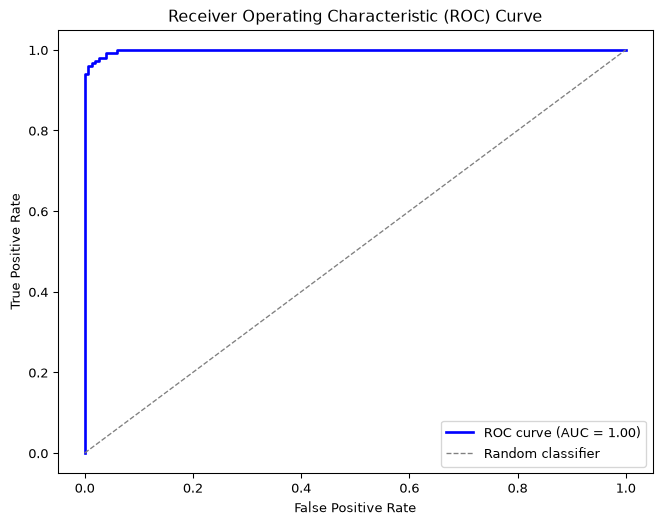

In [6]:
# Compute predicted probabilities for the positive class on the test set
y_probs = model.predict_proba(X_test)

# Compute the ROC curve (FPR and TPR for each threshold)
fpr, tpr, thresholds = compute_roc_curve(y_test, y_probs)
auc_value = compute_auc(fpr, tpr)
sklearn_auc = roc_auc_score(y_test, y_probs)

print(f"Manual AUC:       {auc_value:.3f}")
print(f"scikit-learn AUC: {sklearn_auc:.3f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % auc_value)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Breast cancer dataset

This example uses scikit-learn’s breast-cancer dataset. In this dataset,
label 0 denotes a malignant tumour and label 1 denotes a benign tumour.

Dataset shape: (569, 30), Labels: [212 357]
Feature names (first 5): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


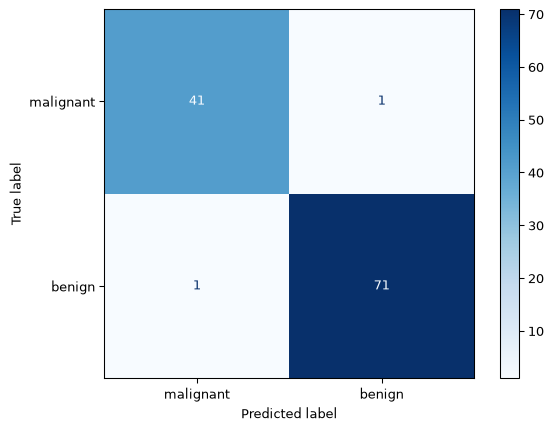

In [7]:
# Goal: Classify tumours as malignant (0) or benign (1)
# Dataset: sklearn.datasets.load_breast_cancer
# Model: Logistic Regression (scikit-learn)

# 1. Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Dataset shape: {X.shape}, Labels: {np.bincount(y)}")
print("Feature names (first 5):", data.feature_names[:5])

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features (important for gradient-based methods)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
clf = SKLogisticRegression(max_iter=5000, random_state=42)
clf.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = clf.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.show()

# Pima Indians diabetes dataset

This dataset illustrates how the classification threshold controls the
trade-off between the true-positive and false-positive rates. The
reported rates are computed from the current train/test split rather
than fixed in the text.

Dataset shape: (768, 8), Labels: [500 268]

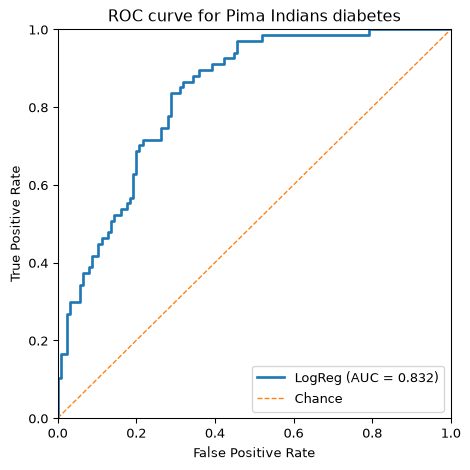

Closest TPR: 0.851
Corresponding FPR: 0.312
Threshold: 0.271

In [8]:
# 1) Load the Pima dataset using its stable OpenML identifier.
dataset = fetch_openml(data_id=37, as_frame=True)
X = dataset.data
y = dataset.target.astype(str).str.lower().map(
    {
        "tested_negative": 0,
        "tested_positive": 1,
        "0": 0,
        "1": 1,
    }
)

if y.isna().any():
    raise ValueError("The OpenML target labels were not recognized.")

y = y.astype(int)
print(f"Dataset shape: {X.shape}, Labels: {np.bincount(y)}")

# 2) Train/test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Scale features (helps LR optimization)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 4) Train Logistic Regression
clf = SKLogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_s, y_train)

# 5) ROC curve & AUC
y_score = clf.predict_proba(X_test_s)[:, 1]     # probability of positive class
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

# 6) Plot
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], lw=1, linestyle="--", label="Chance")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve for Pima Indians diabetes")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Report the operating point closest to a target TPR.
target_tpr = 0.85
idx = np.argmin(np.abs(tpr - target_tpr))

print(f"Closest TPR: {tpr[idx]:.3f}")
print(f"Corresponding FPR: {fpr[idx]:.3f}")
print(f"Threshold: {thresholds[idx]:.3f}")